In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats
from utils import custom_combiner

from sklearn.preprocessing import OneHotEncoder

In [2]:
raw_df = pd.read_csv('../data/f4_data/f4_agg_median.csv')

eda_df = raw_df.copy()
eda_df

,transcript_id,transcript_position,sequence,mean_0,std_0,dwell_0,mean_1,std_1,dwell_1,mean_2,std_2,dwell_2,gene_id,label
0,ENST00000000233,244,AAGACCA,0.00697,3.73,125.0,0.007970,6.650,126.0,0.005980,3.440,80.50,ENSG00000004059,0
1,ENST00000000233,261,CAAACTG,0.00564,2.88,110.0,0.005885,3.000,108.0,0.006790,2.660,94.10,ENSG00000004059,0
2,ENST00000000233,316,GAAACAG,0.00631,2.65,106.0,0.006310,3.780,99.5,0.006310,1.910,89.20,ENSG00000004059,0
3,ENST00000000233,332,AGAACAT,0.00902,5.73,130.0,0.007320,2.635,97.5,0.004980,2.135,89.90,ENSG00000004059,0
4,ENST00000000233,368,AGGACAA,0.00896,6.52,118.0,0.010500,5.660,122.0,0.008695,4.160,85.40,ENSG00000004059,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121833,ENST00000641834,1348,GGGACAT,0.00817,3.20,118.0,0.005310,4.580,116.0,0.004650,3.640,82.10,ENSG00000167747,1
121834,ENST00000641834,1429,CTGACAC,0.00618,3.69,112.0,0.009600,9.140,116.0,0.004820,3.440,80.60,ENSG00000167747,0
121835,ENST00000641834,1531,TGGACAC,0.00697,3.83,114.0,0.005725,4.440,114.0,0.005790,1.925,84.50,ENSG00000167747,1
121836,ENST00000641834,1537,CTGACCA,0.00660,3.16,110.0,0.006810,5.790,124.0,0.006310,2.330,82.00,ENSG00000167747,0


## 1. One Hot Encoding for 5-mer sequence

In [3]:
# Split the sequence into 3 5-mers (the current positions and the 2 flanking positions)
eda_df['seq_5mer_0'] = eda_df['sequence'].str[0:5]
eda_df['seq_5mer_1'] = eda_df['sequence'].str[1:6]
eda_df['seq_5mer_2'] = eda_df['sequence'].str[2:7]

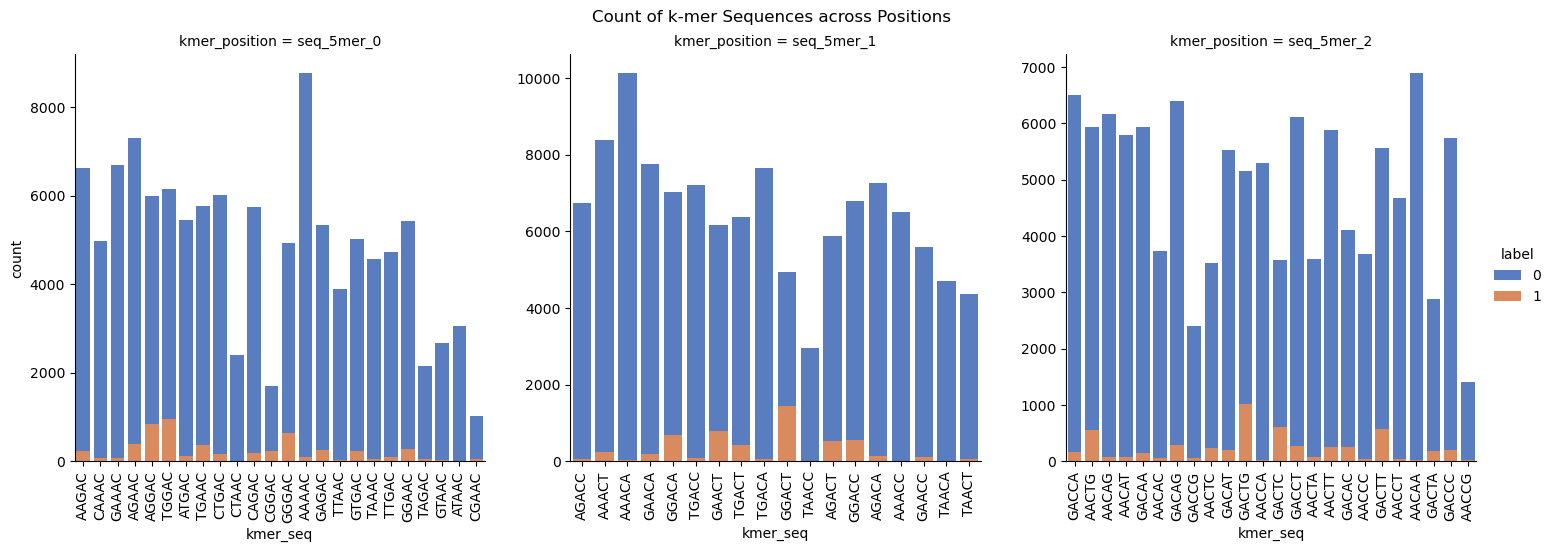

In [4]:
seq_df_p = pd.melt(eda_df, id_vars=['label'], value_vars=['seq_5mer_0', 'seq_5mer_1', 'seq_5mer_2'], var_name='kmer_position', value_name='kmer_seq')

g = sns.catplot(seq_df_p, 
              x='kmer_seq', hue='label', col='kmer_position', kind='count',
              dodge=False, palette='muted',
              sharex=False, sharey=False)
g.tick_params(axis='x', rotation=90)
g.fig.suptitle('Count of k-mer Sequences across Positions', y=1.02)
plt.show()

In [5]:
# def custom_combiner(feature, category):
#     # Create Custom Column Name e.g. seq_5mer_0_AAGAC
#     return str(feature) + "_" + str(category)

enc = OneHotEncoder(handle_unknown='ignore',
                    feature_name_combiner=custom_combiner
)

seq_cols = ['seq_5mer_0', 'seq_5mer_1', 'seq_5mer_2']
enc.fit(eda_df[seq_cols])

encoded_cols = enc.get_feature_names_out(seq_cols)
print(f'No. of Columns Created after One Hot Encoding: {len(encoded_cols)}')

encoded_df = enc.transform(eda_df[seq_cols]).toarray()
encoded_df = pd.DataFrame(encoded_df, columns=encoded_cols)
display(encoded_df)

# joblib.dump(enc, '../resources/kmer_seq_onehotencoder.joblib')

No. of Columns Created after One Hot Encoding: 66


,seq_5mer_0_AAAAC,seq_5mer_0_AAGAC,seq_5mer_0_AGAAC,seq_5mer_0_AGGAC,seq_5mer_0_ATAAC,seq_5mer_0_ATGAC,seq_5mer_0_CAAAC,seq_5mer_0_CAGAC,seq_5mer_0_CGAAC,seq_5mer_0_CGGAC,...,seq_5mer_2_GACAG,seq_5mer_2_GACAT,seq_5mer_2_GACCA,seq_5mer_2_GACCC,seq_5mer_2_GACCG,seq_5mer_2_GACCT,seq_5mer_2_GACTA,seq_5mer_2_GACTC,seq_5mer_2_GACTG,seq_5mer_2_GACTT
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
121834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
121835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
121836,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
eda_encoded_df = pd.concat([
    eda_df.drop(columns=['sequence', 'seq_5mer_0', 'seq_5mer_1', 'seq_5mer_2']),
    encoded_df], axis=1)

eda_encoded_df

,transcript_id,transcript_position,mean_0,std_0,dwell_0,mean_1,std_1,dwell_1,mean_2,std_2,...,seq_5mer_2_GACAG,seq_5mer_2_GACAT,seq_5mer_2_GACCA,seq_5mer_2_GACCC,seq_5mer_2_GACCG,seq_5mer_2_GACCT,seq_5mer_2_GACTA,seq_5mer_2_GACTC,seq_5mer_2_GACTG,seq_5mer_2_GACTT
0,ENST00000000233,244,0.00697,3.73,125.0,0.007970,6.650,126.0,0.005980,3.440,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ENST00000000233,261,0.00564,2.88,110.0,0.005885,3.000,108.0,0.006790,2.660,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ENST00000000233,316,0.00631,2.65,106.0,0.006310,3.780,99.5,0.006310,1.910,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ENST00000000233,332,0.00902,5.73,130.0,0.007320,2.635,97.5,0.004980,2.135,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ENST00000000233,368,0.00896,6.52,118.0,0.010500,5.660,122.0,0.008695,4.160,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121833,ENST00000641834,1348,0.00817,3.20,118.0,0.005310,4.580,116.0,0.004650,3.640,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
121834,ENST00000641834,1429,0.00618,3.69,112.0,0.009600,9.140,116.0,0.004820,3.440,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
121835,ENST00000641834,1531,0.00697,3.83,114.0,0.005725,4.440,114.0,0.005790,1.925,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
121836,ENST00000641834,1537,0.00660,3.16,110.0,0.006810,5.790,124.0,0.006310,2.330,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# eda_encoded_df.to_csv('../data/encode_test_data/new_ohe_basic.csv', index=False)

## 2. Reduce Skewness for original numerical features

In [8]:
# Check skewness for numerical features
num_cols = eda_df.select_dtypes(include=['number']).drop(columns=['transcript_position', 'label']).columns

feat_skewness = eda_encoded_df[num_cols].skew().sort_values(ascending=False) 
display(feat_skewness)
skewed_feats = feat_skewness[abs(feat_skewness) >= 0.4]
print('\n Initial Skewness: ')
display(skewed_feats)


skewed_cols = skewed_feats.index

ns_cols = []

for col in skewed_cols:
    log_col = "log_" + col
    ns_cols.append(log_col)

    # Perform log transformation
    eda_encoded_df[log_col] = np.log(eda_encoded_df[col])
    # eda_encoded_df.drop(columns=col, inplace=True)

print('\n Removed Skewness: ')
check_skewness = eda_encoded_df[ns_cols].skew()
check_skewness

mean_2     1.255480
std_2      1.213466
mean_0     1.155775
mean_1     1.091775
std_0      1.008965
std_1      0.580250
dwell_1   -0.001812
dwell_2   -0.036010
dwell_0   -0.369485
dtype: float64


 Initial Skewness: 


mean_2    1.255480
std_2     1.213466
mean_0    1.155775
mean_1    1.091775
std_0     1.008965
std_1     0.580250
dtype: float64


 Removed Skewness: 


log_mean_2    0.573485
log_std_2     0.399574
log_mean_0    0.455854
log_mean_1    0.421472
log_std_0     0.284243
log_std_1     0.032583
dtype: float64

In [9]:
# eda_encoded_df.to_csv('../data/encode_test_data/new_ohe_basic_transformation.csv', index=False)

## 3. Create New Features

In [10]:
new_feat_df = eda_encoded_df.copy()
new_feat_df

,transcript_id,transcript_position,mean_0,std_0,dwell_0,mean_1,std_1,dwell_1,mean_2,std_2,...,seq_5mer_2_GACTA,seq_5mer_2_GACTC,seq_5mer_2_GACTG,seq_5mer_2_GACTT,log_mean_2,log_std_2,log_mean_0,log_mean_1,log_std_0,log_std_1
0,ENST00000000233,244,0.00697,3.73,125.0,0.007970,6.650,126.0,0.005980,3.440,...,0.0,0.0,0.0,0.0,-5.119335,1.235471,-4.966140,-4.832071,1.316408,1.894617
1,ENST00000000233,261,0.00564,2.88,110.0,0.005885,3.000,108.0,0.006790,2.660,...,0.0,0.0,0.0,0.0,-4.992304,0.978326,-5.177871,-5.135349,1.057790,1.098612
2,ENST00000000233,316,0.00631,2.65,106.0,0.006310,3.780,99.5,0.006310,1.910,...,0.0,0.0,0.0,0.0,-5.065620,0.647103,-5.065620,-5.065620,0.974560,1.329724
3,ENST00000000233,332,0.00902,5.73,130.0,0.007320,2.635,97.5,0.004980,2.135,...,0.0,0.0,0.0,0.0,-5.302325,0.758467,-4.708311,-4.917145,1.745716,0.968883
4,ENST00000000233,368,0.00896,6.52,118.0,0.010500,5.660,122.0,0.008695,4.160,...,0.0,0.0,0.0,0.0,-4.745007,1.425515,-4.714985,-4.556380,1.874874,1.733424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121833,ENST00000641834,1348,0.00817,3.20,118.0,0.005310,4.580,116.0,0.004650,3.640,...,0.0,0.0,0.0,0.0,-5.370888,1.291984,-4.807286,-5.238163,1.163151,1.521699
121834,ENST00000641834,1429,0.00618,3.69,112.0,0.009600,9.140,116.0,0.004820,3.440,...,0.0,0.0,0.0,0.0,-5.334981,1.235471,-5.086437,-4.645992,1.305626,2.212660
121835,ENST00000641834,1531,0.00697,3.83,114.0,0.005725,4.440,114.0,0.005790,1.925,...,0.0,0.0,0.0,0.0,-5.151623,0.654926,-4.966140,-5.162913,1.342865,1.490654
121836,ENST00000641834,1537,0.00660,3.16,110.0,0.006810,5.790,124.0,0.006310,2.330,...,0.0,0.0,0.0,0.0,-5.065620,0.845868,-5.020686,-4.989363,1.150572,1.756132


In [11]:
new_feat_df['all_mean'] = new_feat_df[['mean_0', 'mean_1', 'mean_2']].mean(axis=1)
new_feat_df['all_std'] = new_feat_df[['std_0', 'std_1', 'std_2']].mean(axis=1)
new_feat_df['all_dwell'] = new_feat_df[['dwell_0', 'dwell_1', 'dwell_2']].mean(axis=1)

In [12]:
new_feat_df

,transcript_id,transcript_position,mean_0,std_0,dwell_0,mean_1,std_1,dwell_1,mean_2,std_2,...,seq_5mer_2_GACTT,log_mean_2,log_std_2,log_mean_0,log_mean_1,log_std_0,log_std_1,all_mean,all_std,all_dwell
0,ENST00000000233,244,0.00697,3.73,125.0,0.007970,6.650,126.0,0.005980,3.440,...,0.0,-5.119335,1.235471,-4.966140,-4.832071,1.316408,1.894617,0.006973,4.606667,110.500000
1,ENST00000000233,261,0.00564,2.88,110.0,0.005885,3.000,108.0,0.006790,2.660,...,0.0,-4.992304,0.978326,-5.177871,-5.135349,1.057790,1.098612,0.006105,2.846667,104.033333
2,ENST00000000233,316,0.00631,2.65,106.0,0.006310,3.780,99.5,0.006310,1.910,...,0.0,-5.065620,0.647103,-5.065620,-5.065620,0.974560,1.329724,0.006310,2.780000,98.233333
3,ENST00000000233,332,0.00902,5.73,130.0,0.007320,2.635,97.5,0.004980,2.135,...,0.0,-5.302325,0.758467,-4.708311,-4.917145,1.745716,0.968883,0.007107,3.500000,105.800000
4,ENST00000000233,368,0.00896,6.52,118.0,0.010500,5.660,122.0,0.008695,4.160,...,0.0,-4.745007,1.425515,-4.714985,-4.556380,1.874874,1.733424,0.009385,5.446667,108.466667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121833,ENST00000641834,1348,0.00817,3.20,118.0,0.005310,4.580,116.0,0.004650,3.640,...,0.0,-5.370888,1.291984,-4.807286,-5.238163,1.163151,1.521699,0.006043,3.806667,105.366667
121834,ENST00000641834,1429,0.00618,3.69,112.0,0.009600,9.140,116.0,0.004820,3.440,...,0.0,-5.334981,1.235471,-5.086437,-4.645992,1.305626,2.212660,0.006867,5.423333,102.866667
121835,ENST00000641834,1531,0.00697,3.83,114.0,0.005725,4.440,114.0,0.005790,1.925,...,0.0,-5.151623,0.654926,-4.966140,-5.162913,1.342865,1.490654,0.006162,3.398333,104.166667
121836,ENST00000641834,1537,0.00660,3.16,110.0,0.006810,5.790,124.0,0.006310,2.330,...,0.0,-5.065620,0.845868,-5.020686,-4.989363,1.150572,1.756132,0.006573,3.760000,105.333333


In [13]:
# new_feat_df.drop(columns=['mean_0', 'std_0', 'mean_1', 'std_1', 'mean_2', 'std_2']).to_csv('../data/encode_test_data/new_ohe_basic_transformation_others_f4.csv', index=False)

## 4. Add more summarized info from Data Parsing

In [14]:
new_agg_df = pd.read_csv('../data/f5_data/f5_agg_iqr.csv')

common_cols = ['gene_id', 'transcript_id', 'transcript_position','label']

merged_df = pd.merge(new_feat_df, new_agg_df, on=common_cols, how='left')
merged_df

,transcript_id,transcript_position,mean_0,std_0,dwell_0,mean_1,std_1,dwell_1,mean_2,std_2,...,sequence,mean_0_iqr,std_0_iqr,dwell_0_iqr,mean_1_iqr,std_1_iqr,dwell_1_iqr,mean_2_iqr,std_2_iqr,dwell_2_iqr
0,ENST00000000233,244,0.00697,3.73,125.0,0.007970,6.650,126.0,0.005980,3.440,...,AAGACCA,0.006680,1.5900,3.0,0.007200,5.5300,4.00,0.005980,3.7300,3.000
1,ENST00000000233,261,0.00564,2.88,110.0,0.005885,3.000,108.0,0.006790,2.660,...,CAAACTG,0.003650,1.3000,4.0,0.004000,1.1900,4.00,0.005047,1.3225,2.925
2,ENST00000000233,316,0.00631,2.65,106.0,0.006310,3.780,99.5,0.006310,1.910,...,GAAACAG,0.005230,1.2100,1.0,0.005320,1.0300,3.10,0.004450,0.9000,1.700
3,ENST00000000233,332,0.00902,5.73,130.0,0.007320,2.635,97.5,0.004980,2.135,...,AGAACAT,0.006925,3.3500,3.0,0.005635,0.9700,2.30,0.003652,0.7775,4.250
4,ENST00000000233,368,0.00896,6.52,118.0,0.010500,5.660,122.0,0.008695,4.160,...,AGGACAA,0.008130,1.6750,3.0,0.006710,2.1450,2.00,0.006063,1.5875,3.275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121833,ENST00000641834,1348,0.00817,3.20,118.0,0.005310,4.580,116.0,0.004650,3.640,...,GGGACAT,0.005750,1.2700,2.0,0.005980,2.3200,5.00,0.004040,1.5500,4.100
121834,ENST00000641834,1429,0.00618,3.69,112.0,0.009600,9.140,116.0,0.004820,3.440,...,CTGACAC,0.005950,2.0100,3.0,0.008410,3.4400,4.00,0.003270,1.2000,3.000
121835,ENST00000641834,1531,0.00697,3.83,114.0,0.005725,4.440,114.0,0.005790,1.925,...,TGGACAC,0.004540,1.7575,2.0,0.004568,2.2375,2.25,0.003025,0.7350,1.975
121836,ENST00000641834,1537,0.00660,3.16,110.0,0.006810,5.790,124.0,0.006310,2.330,...,CTGACCA,0.005110,0.9500,4.0,0.003820,3.3400,4.00,0.003090,1.1300,3.300


In [15]:
new_cols = ['mean_0_iqr',
            'std_0_iqr', 
            'dwell_0_iqr', 
            'mean_1_iqr', 
            'std_1_iqr', 
            'dwell_1_iqr', 
            'mean_2_iqr', 
            'std_2_iqr',
            'dwell_2_iqr']

zero_cols = merged_df[new_cols].loc[:, (merged_df == 0).any()].select_dtypes(include=['number']).columns
print(f'Features with zero values: {zero_cols}') # no columns with zero values

# Remove Features with zero values
new_cols = list(filter(lambda x: x not in zero_cols, new_cols))

feat_skewness = merged_df[new_cols].skew().sort_values(ascending=False) 
skewed_feats = feat_skewness[abs(feat_skewness) >= 0.4]
print('\n Initial Skewness: ')
display(skewed_feats)

skewed_cols = skewed_feats.index

ns_cols = []

test_skew_df = merged_df.copy()

for col in skewed_cols:
    log_col = "log_" + col
    ns_cols.append(log_col)

    # Perform log transformation
    test_skew_df[log_col] = np.log(test_skew_df[col])
    test_skew_df.drop(columns=col, inplace=True)


print('\n Removed Skewness: ')
check_skewness = test_skew_df[ns_cols].skew()
check_skewness

Features with zero values: Index(['dwell_0_iqr'], dtype='object')

 Initial Skewness: 


dwell_2_iqr    2.262980
std_2_iqr      1.440215
dwell_1_iqr    1.233803
std_0_iqr      1.192058
mean_2_iqr     1.043982
mean_0_iqr     0.922490
mean_1_iqr     0.835282
std_1_iqr      0.612928
dtype: float64


 Removed Skewness: 


log_dwell_2_iqr    0.240140
log_std_2_iqr      0.178780
log_dwell_1_iqr   -0.065463
log_std_0_iqr      0.106719
log_mean_2_iqr    -0.025255
log_mean_0_iqr    -0.061593
log_mean_1_iqr    -0.149262
log_std_1_iqr     -0.168302
dtype: float64

In [16]:
final_df = test_skew_df.drop(columns=[
    'sequence', 'mean_0', 'mean_1', 'mean_2', 'std_0', 'std_1', 'std_2'
])

final_df.columns

Index(['transcript_id', 'transcript_position', 'dwell_0', 'dwell_1', 'dwell_2',
       'gene_id', 'label', 'seq_5mer_0_AAAAC', 'seq_5mer_0_AAGAC',
       'seq_5mer_0_AGAAC', 'seq_5mer_0_AGGAC', 'seq_5mer_0_ATAAC',
       'seq_5mer_0_ATGAC', 'seq_5mer_0_CAAAC', 'seq_5mer_0_CAGAC',
       'seq_5mer_0_CGAAC', 'seq_5mer_0_CGGAC', 'seq_5mer_0_CTAAC',
       'seq_5mer_0_CTGAC', 'seq_5mer_0_GAAAC', 'seq_5mer_0_GAGAC',
       'seq_5mer_0_GGAAC', 'seq_5mer_0_GGGAC', 'seq_5mer_0_GTAAC',
       'seq_5mer_0_GTGAC', 'seq_5mer_0_TAAAC', 'seq_5mer_0_TAGAC',
       'seq_5mer_0_TGAAC', 'seq_5mer_0_TGGAC', 'seq_5mer_0_TTAAC',
       'seq_5mer_0_TTGAC', 'seq_5mer_1_AAACA', 'seq_5mer_1_AAACC',
       'seq_5mer_1_AAACT', 'seq_5mer_1_AGACA', 'seq_5mer_1_AGACC',
       'seq_5mer_1_AGACT', 'seq_5mer_1_GAACA', 'seq_5mer_1_GAACC',
       'seq_5mer_1_GAACT', 'seq_5mer_1_GGACA', 'seq_5mer_1_GGACC',
       'seq_5mer_1_GGACT', 'seq_5mer_1_TAACA', 'seq_5mer_1_TAACC',
       'seq_5mer_1_TAACT', 'seq_5mer_1_TGACA', 's

22


label              1.000000
all_dwell          0.118979
log_dwell_1_iqr    0.098338
dwell_0            0.094227
log_dwell_2_iqr    0.079009
log_std_0_iqr      0.077040
log_std_1_iqr      0.068131
dwell_1            0.058608
log_std_2_iqr      0.048084
log_std_0          0.046243
all_mean           0.044743
dwell_0_iqr        0.042546
log_mean_0         0.039775
log_mean_2         0.039448
log_mean_1_iqr     0.038044
log_mean_0_iqr     0.037865
log_mean_2_iqr     0.033936
dwell_2            0.030921
log_mean_1         0.019703
log_std_2          0.009668
log_std_1         -0.001586
all_std           -0.011423
Name: label, dtype: float64

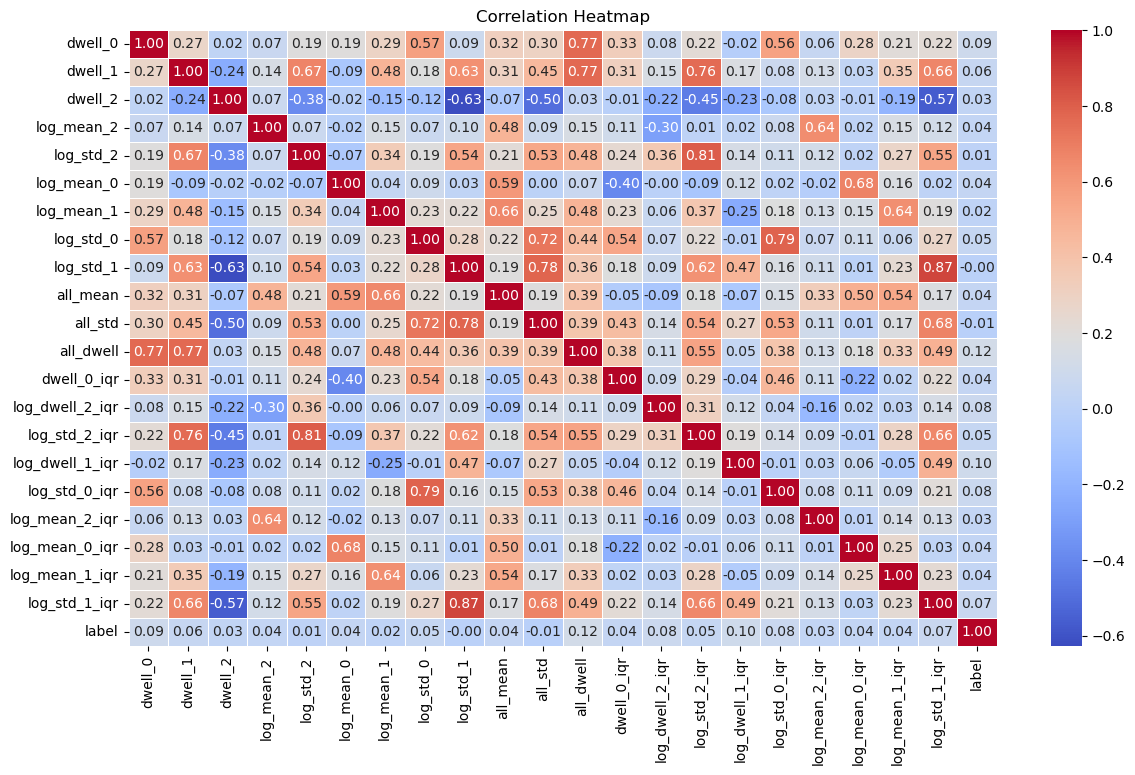

In [19]:
info_cols = ['transcript_id', 'transcript_position', 'gene_id']

col_order = ['dwell_0', 'dwell_1', 'dwell_2', 
      #        'seq_5mer_0_AAAAC', 'seq_5mer_0_AAGAC',
      #  'seq_5mer_0_AGAAC', 'seq_5mer_0_AGGAC', 'seq_5mer_0_ATAAC',
      #  'seq_5mer_0_ATGAC', 'seq_5mer_0_CAAAC', 'seq_5mer_0_CAGAC',
      #  'seq_5mer_0_CGAAC', 'seq_5mer_0_CGGAC', 'seq_5mer_0_CTAAC',
      #  'seq_5mer_0_CTGAC', 'seq_5mer_0_GAAAC', 'seq_5mer_0_GAGAC',
      #  'seq_5mer_0_GGAAC', 'seq_5mer_0_GGGAC', 'seq_5mer_0_GTAAC',
      #  'seq_5mer_0_GTGAC', 'seq_5mer_0_TAAAC', 'seq_5mer_0_TAGAC',
      #  'seq_5mer_0_TGAAC', 'seq_5mer_0_TGGAC', 'seq_5mer_0_TTAAC',
      #  'seq_5mer_0_TTGAC', 'seq_5mer_1_AAACA', 'seq_5mer_1_AAACC',
      #  'seq_5mer_1_AAACT', 'seq_5mer_1_AGACA', 'seq_5mer_1_AGACC',
      #  'seq_5mer_1_AGACT', 'seq_5mer_1_GAACA', 'seq_5mer_1_GAACC',
      #  'seq_5mer_1_GAACT', 'seq_5mer_1_GGACA', 'seq_5mer_1_GGACC',
      #  'seq_5mer_1_GGACT', 'seq_5mer_1_TAACA', 'seq_5mer_1_TAACC',
      #  'seq_5mer_1_TAACT', 'seq_5mer_1_TGACA', 'seq_5mer_1_TGACC',
      #  'seq_5mer_1_TGACT', 'seq_5mer_2_AACAA', 'seq_5mer_2_AACAC',
      #  'seq_5mer_2_AACAG', 'seq_5mer_2_AACAT', 'seq_5mer_2_AACCA',
      #  'seq_5mer_2_AACCC', 'seq_5mer_2_AACCG', 'seq_5mer_2_AACCT',
      #  'seq_5mer_2_AACTA', 'seq_5mer_2_AACTC', 'seq_5mer_2_AACTG',
      #  'seq_5mer_2_AACTT', 'seq_5mer_2_GACAA', 'seq_5mer_2_GACAC',
      #  'seq_5mer_2_GACAG', 'seq_5mer_2_GACAT', 'seq_5mer_2_GACCA',
      #  'seq_5mer_2_GACCC', 'seq_5mer_2_GACCG', 'seq_5mer_2_GACCT',
      #  'seq_5mer_2_GACTA', 'seq_5mer_2_GACTC', 'seq_5mer_2_GACTG',
      #  'seq_5mer_2_GACTT', 
       'log_mean_2', 'log_std_2', 'log_mean_0',
       'log_mean_1', 'log_std_0', 'log_std_1', 'all_mean', 'all_std',
       'all_dwell', 'dwell_0_iqr', 'log_dwell_2_iqr', 'log_std_2_iqr',
       'log_dwell_1_iqr', 'log_std_0_iqr', 'log_mean_2_iqr', 'log_mean_0_iqr',
       'log_mean_1_iqr', 'log_std_1_iqr', 'label']
print(len(col_order))

corr_ft_df = final_df.drop(columns=info_cols)

corr_ft = corr_ft_df[col_order].corr(method='spearman')
display(corr_ft['label'].sort_values(ascending=False))

plt.figure(figsize=(14, 8))
sns.heatmap(corr_ft, 
            annot=True, 
            cmap="coolwarm", 
            fmt=".2f", 
            linewidths=0.5)
plt.title("Correlation Heatmap")
plt.xticks(rotation=90)
plt.show()

In [18]:
final_df = final_df[[
    'transcript_id', 'transcript_position', 'gene_id', 'label', 
    'log_mean_0', 'log_mean_1', 'log_mean_2',
    'log_std_0', 'log_std_1', 'log_std_2', 
    'dwell_0', 'dwell_1', 'dwell_2',
    'seq_5mer_0_AAAAC', 'seq_5mer_0_AAGAC',
    'seq_5mer_0_AGAAC', 'seq_5mer_0_AGGAC', 'seq_5mer_0_ATAAC',
    'seq_5mer_0_ATGAC', 'seq_5mer_0_CAAAC', 'seq_5mer_0_CAGAC',
    'seq_5mer_0_CGAAC', 'seq_5mer_0_CGGAC', 'seq_5mer_0_CTAAC',
    'seq_5mer_0_CTGAC', 'seq_5mer_0_GAAAC', 'seq_5mer_0_GAGAC',
    'seq_5mer_0_GGAAC', 'seq_5mer_0_GGGAC', 'seq_5mer_0_GTAAC',
    'seq_5mer_0_GTGAC', 'seq_5mer_0_TAAAC', 'seq_5mer_0_TAGAC',
    'seq_5mer_0_TGAAC', 'seq_5mer_0_TGGAC', 'seq_5mer_0_TTAAC',
    'seq_5mer_0_TTGAC', 'seq_5mer_1_AAACA', 'seq_5mer_1_AAACC',
    'seq_5mer_1_AAACT', 'seq_5mer_1_AGACA', 'seq_5mer_1_AGACC',
    'seq_5mer_1_AGACT', 'seq_5mer_1_GAACA', 'seq_5mer_1_GAACC',
    'seq_5mer_1_GAACT', 'seq_5mer_1_GGACA', 'seq_5mer_1_GGACC',
    'seq_5mer_1_GGACT', 'seq_5mer_1_TAACA', 'seq_5mer_1_TAACC',
    'seq_5mer_1_TAACT', 'seq_5mer_1_TGACA', 'seq_5mer_1_TGACC',
    'seq_5mer_1_TGACT', 'seq_5mer_2_AACAA', 'seq_5mer_2_AACAC',
    'seq_5mer_2_AACAG', 'seq_5mer_2_AACAT', 'seq_5mer_2_AACCA',
    'seq_5mer_2_AACCC', 'seq_5mer_2_AACCG', 'seq_5mer_2_AACCT',
    'seq_5mer_2_AACTA', 'seq_5mer_2_AACTC', 'seq_5mer_2_AACTG',
    'seq_5mer_2_AACTT', 'seq_5mer_2_GACAA', 'seq_5mer_2_GACAC',
    'seq_5mer_2_GACAG', 'seq_5mer_2_GACAT', 'seq_5mer_2_GACCA',
    'seq_5mer_2_GACCC', 'seq_5mer_2_GACCG', 'seq_5mer_2_GACCT',
    'seq_5mer_2_GACTA', 'seq_5mer_2_GACTC', 'seq_5mer_2_GACTG',
    'seq_5mer_2_GACTT', 
    'all_mean', 'all_std', 'all_dwell', 
    'log_mean_0_iqr', 'log_mean_1_iqr', 'log_mean_2_iqr',
    'log_std_0_iqr', 'log_std_1_iqr', 'log_std_2_iqr',
    'dwell_0_iqr', 'log_dwell_1_iqr', 'log_dwell_2_iqr']]

display(final_df)

# final_df.to_csv('../data/f5_data/f5_final.csv', index=False)

,transcript_id,transcript_position,gene_id,label,log_mean_0,log_mean_1,log_mean_2,log_std_0,log_std_1,log_std_2,...,all_dwell,log_mean_0_iqr,log_mean_1_iqr,log_mean_2_iqr,log_std_0_iqr,log_std_1_iqr,log_std_2_iqr,dwell_0_iqr,log_dwell_1_iqr,log_dwell_2_iqr
0,ENST00000000233,244,ENSG00000004059,0,-4.966140,-4.832071,-5.119335,1.316408,1.894617,1.235471,...,110.500000,-5.008637,-4.933674,-5.119335,0.463734,1.710188,1.316408,3.0,1.386294,1.098612
1,ENST00000000233,261,ENSG00000004059,0,-5.177871,-5.135349,-4.992304,1.057790,1.098612,0.978326,...,104.033333,-5.613028,-5.521461,-5.288862,0.262364,0.173953,0.279524,4.0,1.386294,1.073294
2,ENST00000000233,316,ENSG00000004059,0,-5.065620,-5.065620,-5.065620,0.974560,1.329724,0.647103,...,98.233333,-5.253344,-5.236282,-5.414851,0.190620,0.029559,-0.105361,1.0,1.131402,0.530628
3,ENST00000000233,332,ENSG00000004059,0,-4.708311,-4.917145,-5.302325,1.745716,0.968883,0.758467,...,105.800000,-4.972617,-5.178758,-5.612343,1.208960,-0.030459,-0.251672,3.0,0.832909,1.446919
4,ENST00000000233,368,ENSG00000004059,0,-4.714985,-4.556380,-4.745007,1.874874,1.733424,1.425515,...,108.466667,-4.812194,-5.004156,-5.105633,0.515813,0.763140,0.462160,3.0,0.693147,1.186318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121833,ENST00000641834,1348,ENSG00000167747,1,-4.807286,-5.238163,-5.370888,1.163151,1.521699,1.291984,...,105.366667,-5.158555,-5.119335,-5.511511,0.239017,0.841567,0.438255,2.0,1.609438,1.410987
121834,ENST00000641834,1429,ENSG00000167747,0,-5.086437,-4.645992,-5.334981,1.305626,2.212660,1.235471,...,102.866667,-5.124364,-4.778334,-5.722965,0.698135,1.235471,0.182322,3.0,1.386294,1.098612
121835,ENST00000641834,1531,ENSG00000167747,1,-4.966140,-5.162913,-5.151623,1.342865,1.490654,0.654926,...,104.166667,-5.394828,-5.388789,-5.800844,0.563892,0.805359,-0.307885,2.0,0.810930,0.680568
121836,ENST00000641834,1537,ENSG00000167747,0,-5.020686,-4.989363,-5.065620,1.150572,1.756132,0.845868,...,105.333333,-5.276556,-5.567505,-5.779584,-0.051293,1.205971,0.122218,4.0,1.386294,1.193922
